# 6.4 Training Neural Networks with multiple inputs

This notebook is adapted from the code taken from

https://github.com/Ceyron/machine-learning-and-simulation/blob/main/english/neural_network_sine_learning/nn_learns_sine_function_with_autodiff_in_julia_lux.jl



In Notebook 3.6, there was an Class Demo that asked to use $f_{model}(x_1,x_2)=a_0+a_1 x_1+a_2 x_2+a_3x_1x_2+a_4 x_1^2+a_5 x_2^2$  to fit the function $y=\sin(x_1 x_2)$.   We will do the same problem again here.   You will find that you could not get a good fit mainly because $f_{model}(x_1,x_2)$ is not a good general function approximator.  Later in this notebook,  we will try to use a relatively complex Neural Network to see if we fit it better to the data generated from $y=\sin(x_1 x_2)$.


This notebook uses the Neural Network package in Julia, `Lux.jl` to represent the Neural network. 

Importing all packages

In [5]:
using Lux
using Random
using Zygote
using Optimisers
using CairoMakie
using Distributions
using Statistics
using Printf
using Optimization
using OptimizationOptimisers
using ComponentArrays

Draw samples to create a toy data set $y=\sin(x_1x_2)$.  Here, we will generate our own data.

In [6]:
N_SAMPLES = 1_000

# Our Pseudo-Random Number Generator
rng = Xoshiro(42)

x1_samples = rand(
    rng,
    Uniform(0.0, 2 * π),
    (1,N_SAMPLES),
)

x2_samples = rand(
    rng,
    Uniform(0.0, 2 * π),
    (1,N_SAMPLES),
)


y_noise = rand(
    rng,
    Normal(0.0, 0.01),
    (1,N_SAMPLES),
)

y_samples = Float32.(sin.(x1_samples.*x2_samples) .+ 0.01*y_noise)
x_samples=[Float32.(x1_samples);Float32.(x2_samples)]


2×1000 Matrix{Float32}:
 1.0906   2.02106  1.62474   1.04576  …  4.90091  4.47217  5.38323  1.0641
 2.65313  4.63591  0.633562  2.01732     5.54129  3.88784  5.62645  0.766778

The problem that we are interested in has two inputs and 1 output.  PLEASE note that the input x_samples is a vector of matrix size 2 x N_SAMPLES and the output y_samples is a  vector of matrix of size 1 x N_SAMPLES.   If you use the `Lux.jl` package, it expects data to be ordered like that

$
\mathbf{x}=\begin{bmatrix} x_{11} &x _{12} & x_{13} & \cdots &x_{1N} \\ x_{21} &x _{22} & x_{23} & \cdots &x_{2N} \end{bmatrix}
$

$\mathbf{y}=\begin{bmatrix} y_{1} &y _{2} & y_{3} & \cdots &y_{N} \end{bmatrix}$

Plot the data to see how it looks like

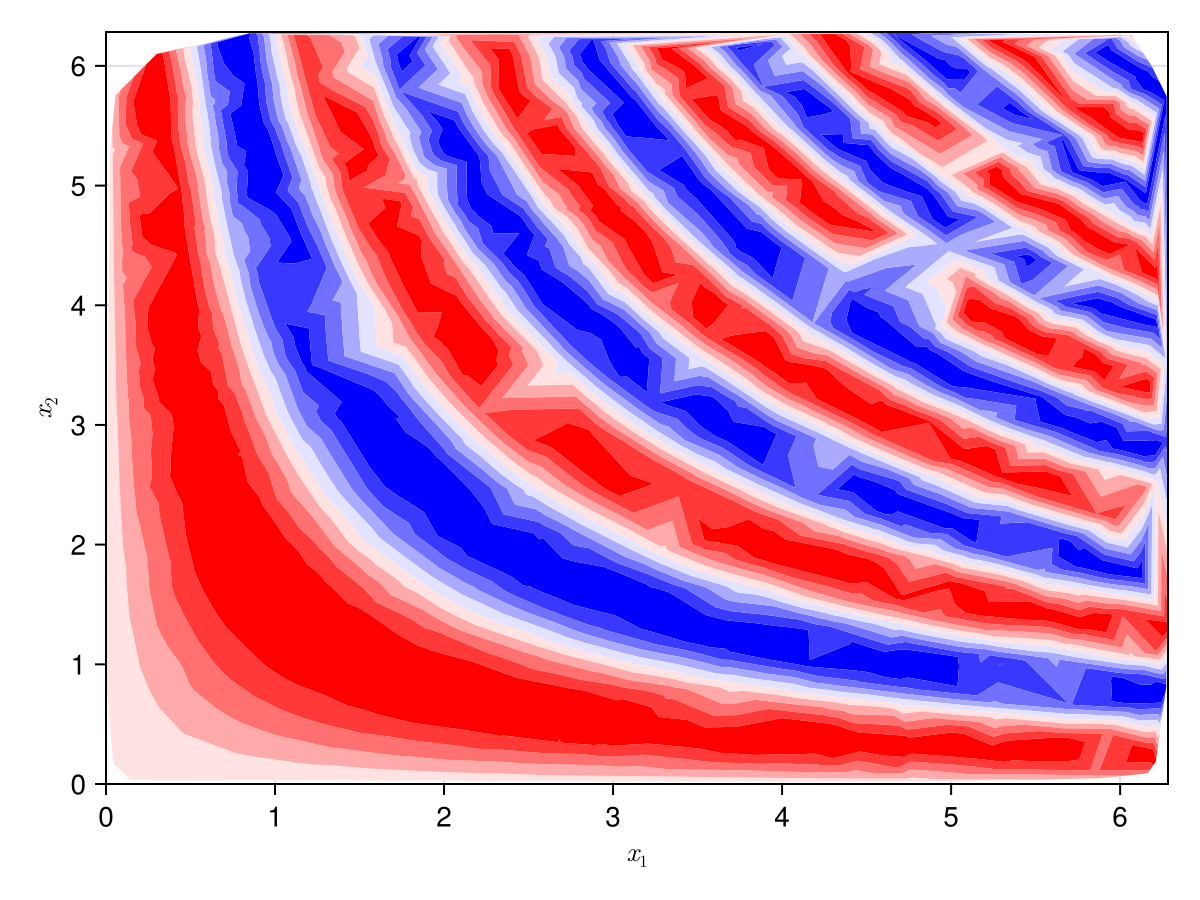

In [7]:
fig = Figure()
ax = CairoMakie.Axis(fig[1, 1], xlabel = L"x_1", ylabel = L"x_2",limits=(0,2π,0,2π))
tricontourf!(ax,x_samples[1,:],x_samples[2,:],y_samples[:],colormap=:bwr)
fig

---

Let's now see if we can use a polynomial 

$f_{model}(x_1,x_2)=a_0+a_1 x_1+a_2 x_2+a_3x_1x_2+a_4 x_1^2+a_5 x_2^2$

to fit this function.  We will use the normal equations to find the coefficients. First construct the $[V]$ matrix

$$
\mathbf{V}=\begin{bmatrix}
1 & x_{11}  & x_{21} & x_{11}x_{21} & x_{11}^2 & x_{21}^2 \\
1 & x_{12}  & x_{22} & x_{12}x_{22} & x_{12}^2 & x_{22}^2 \\
1 & x_{13}  & x_{23} & x_{13}x_{23} & x_{13}^2 & x_{23}^2 \\
\vdots \\
1 & x_{1N}  & x_{2N} & x_{1N}x_{2N} & x_{1N}^2 & x_{2N}^2 \\
\end{bmatrix}
$$


Then we can find the coefficients using the  formula

$$
\vec{a}=(\mathbf{V}^T \mathbf{V})^{-1}\mathbf{V}^T\vec{y}
$$

where $\vec{y}$ is the quantity that you are trying to predict.

In [8]:
V=hcat(ones(N_SAMPLES),x1_samples[:],x2_samples[:],x1_samples[:].*x2_samples[:],x1_samples[:].^2,x2_samples[:].^2)
a=V'*V\(V'*y_samples[:])

6-element Vector{Float64}:
  0.7173151855030183
 -0.19110918250673548
 -0.16981952199684316
  0.010613206345325818
  0.01685952549659496
  0.01359615749223827

Then compute the prediction from $f_{model}$

In [9]:
ypred=a[1].+a[2]*x1_samples[:].+a[3]*x2_samples[:].+a[4]*x1_samples[:].*x2_samples[:].+a[5]*x1_samples[:].^2+a[6]*x2_samples[:].^2

1000-element Vector{Float64}:
  0.20480515696096138
  0.004313921550534505
  0.36010905306287266
  0.2710387763412488
 -0.046515792594417515
  0.2815401206896467
 -0.026294216238426593
 -0.006513504096515951
 -0.017021925991159814
  0.13267018321217608
  ⋮
  0.18562579110990549
  0.5993123725545937
  0.05540093227250331
  0.20812941183664696
 -0.029361296308365703
 -0.049656608112769896
 -0.0703504461495568
 -0.026504621680687512
  0.41948527942760183

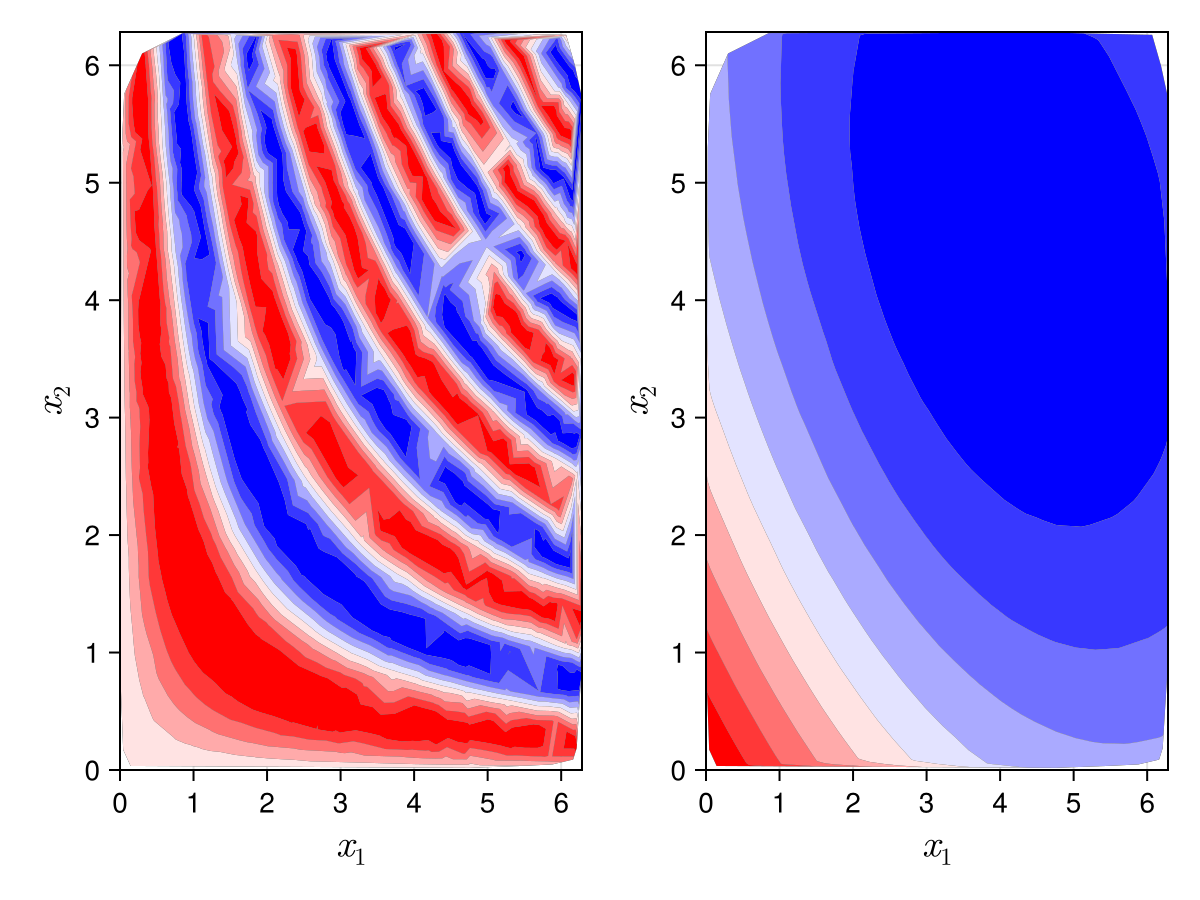

CairoMakie.Screen{IMAGE}


In [10]:
fig = Figure(backgroundcolor=:transparent)
ax1 = CairoMakie.Axis(fig[1, 1], xlabel = L"x_1", ylabel = L"x_2",limits=(0,2π,0,2π),xlabelsize = 20,ylabelsize = 20,backgroundcolor=:transparent)
ax2 = CairoMakie.Axis(fig[1, 2], xlabel = L"x_1", ylabel = L"x_2",limits=(0,2π,0,2π),xlabelsize = 20,ylabelsize = 20,backgroundcolor=:transparent)
tricontourf!(ax1,x_samples[1,:],x_samples[2,:],y_samples[:],colormap=:bwr)
tricontourf!(ax2,x_samples[1,:],x_samples[2,:],ypred,colormap=:bwr)
save("../figures/06p04TrainingMultivariateNeuralNetworks01.png",fig)
display(fig)

As you can see, the prediction using $f_{model}$ is not very good. Now let's try to get a better prediction using a Neural Network.

---

The code below defines the Neural Network Architecture.  This Neural Network has two inputs and one output with 3 hidden layers with ten nodes. This Neural Network is quite complex and should be able model $y=\sin(x_1 x_2)$ much better than the 2nd order polynomial $f_{model}()$ function   in  notebook 3.6.

In [11]:
model = Chain(
    Dense(2 => 10),
    Dense(10 => 10,tanh),
    Dense(10 => 10,tanh),
    Dense(10 => 10,tanh),
    Dense(10 => 1)
)

Chain(
    layer_1 = Dense(2 => 10),                     # 30 parameters
    layer_(2-4) = Dense(10 => 10, tanh),          # 330 (110 x 3) parameters
    layer_5 = Dense(10 => 1),                     # 11 parameters
)         # Total: 371 parameters,
          #        plus 0 states.

A visual representation of the Neural Network is shown below. 

![Alt text for screen readers](../figures/06p04Fig01.svg)

(this figure was made using https://alexlenail.me/NN-SVG/)

Information about the network is printed above.  It has 4 hidden layers, with 371 unknown parameters which we are able to tune with some optimization technique.

The code below initializes the parameters of the network with some random numbers

In [12]:
parameters, layer_states = Lux.setup(rng, model)

((layer_1 = (weight = Float32[-1.0708317 -1.1302087; -0.6040637 -1.1956228; … ; -0.2955299 -0.4776289; -0.7644195 0.7865141], bias = Float32[-0.6321535, -0.6105538, 0.5708269, 0.0036835503, 0.21545537, 0.016626425, 0.1774089, -0.21669406, 0.4291924, 0.7043529]), layer_2 = (weight = Float32[-0.7067458 0.59171075 … -0.19577038 0.29535174; -0.35265473 0.21456157 … 0.74424547 -0.37957725; … ; 0.5083448 -0.056543726 … -0.89865136 0.1288232; 0.7259346 -0.85188794 … 0.2754867 0.45333225], bias = Float32[0.015074015, -0.2217923, 0.09363705, -0.17262654, -0.29449806, 0.059713297, 0.25072336, 0.012980231, -0.11212885, -0.22559524]), layer_3 = (weight = Float32[0.690135 0.011821191 … -0.28916267 0.2724587; -0.11111863 -0.8536415 … -0.6046626 0.28117096; … ; -0.28098673 -0.5443014 … 0.6362686 0.560396; 0.3686039 0.45359918 … 0.23107682 0.746915], bias = Float32[-0.06421895, 0.103636324, -0.17465466, -0.009129529, 0.15563653, 0.2127711, -0.29570895, -0.1882615, -0.16013762, -0.044853814]), layer_4 

Now plot the data and the initial (guess) prediction just to see how far off you are from the actual data.

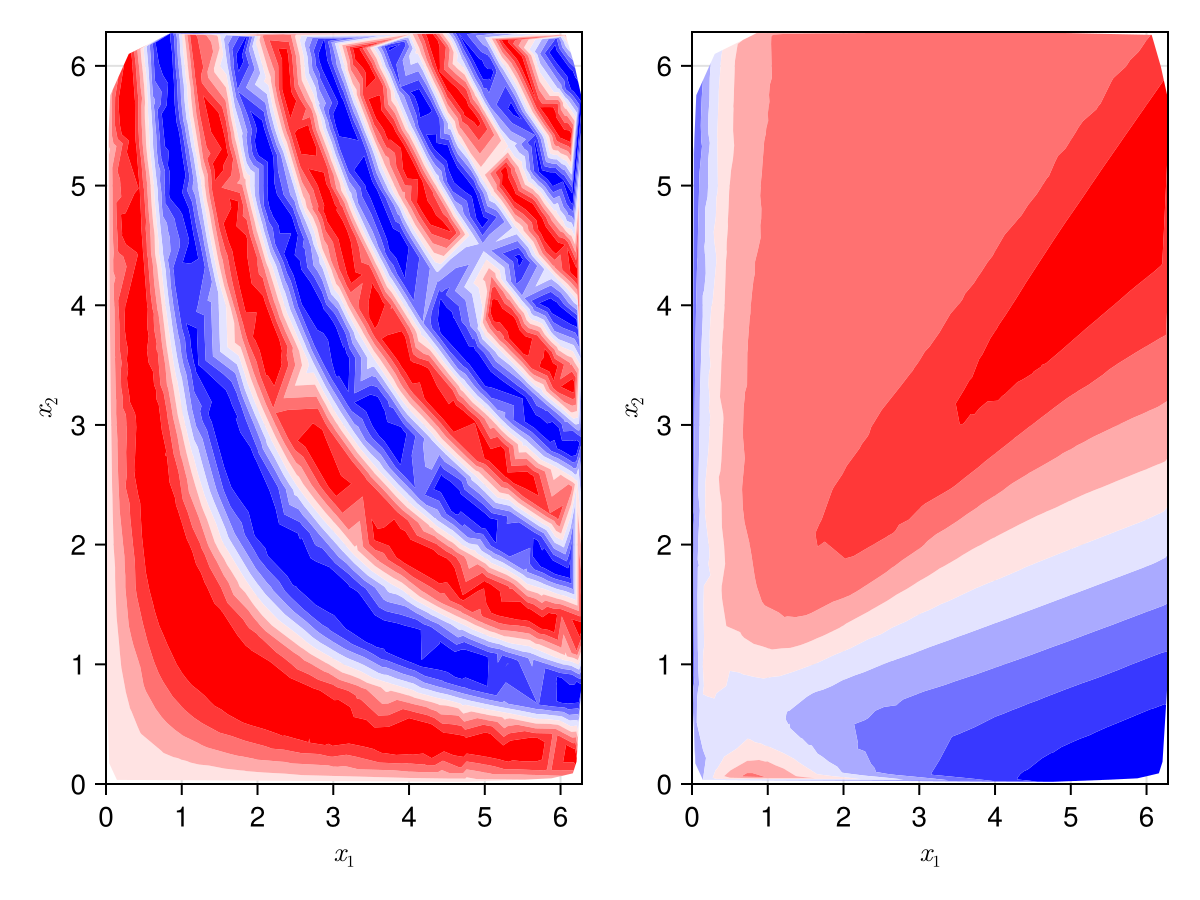

In [13]:
fig = Figure()
ax1 = CairoMakie.Axis(fig[1, 1], xlabel = L"x_1", ylabel = L"x_2",limits=(0,2π,0,2π))
tricontourf!(ax1,x_samples[1,:],x_samples[2,:],y_samples[:],colormap=:bwr)

# predict using Neural Network
y_pred,_=model(x_samples,parameters, layer_states) #note that model expects the input as a row vector


ax2 = CairoMakie.Axis(fig[1, 2], xlabel = L"x_1", ylabel = L"x_2",limits=(0,2π,0,2π))
tricontourf!(ax2,x_samples[1,:],x_samples[2,:],y_pred[:],colormap=:bwr)


fig


The left figure is the data and the right figure is the initial neural network prediction.  The prediction is not good which is expected because the parameters are just random.

Now we will try to find parameters of the Neural Network such that it best fits the data.  First, define the loss function

In [14]:
function loss_fn(p, ls)
    y_prediction, new_ls= model(x_samples, p, ls)
    loss = 0.5 * mean((y_prediction .- y_samples).^2)
    return loss
end

loss_fn (generic function with 1 method)

The code below trains the Neural Network using the standard optimisation functions in Julia

In [15]:
callback = function (p, l)
    if length(loss_history) % 100 == 0
        println("Iteration: $(p.iter), Loss: $l")
    end
    push!(loss_history, l)
    return false
end

adtype = Optimization.AutoZygote()
optf = Optimization.OptimizationFunction(loss_fn, adtype)
optprob = Optimization.OptimizationProblem(optf, ComponentArray(parameters),layer_states)
#optprob = Optimization.OptimizationProblem(optf, ComponentArray(neural_network.u),layer_states)

# Initialize a vector to store loss values
loss_history = Float64[]
neural_network = Optimization.solve(optprob, OptimizationOptimisers.Adam(0.01); callback, maxiters = 10000)


Iteration: 1, Loss: 0.24302177131175995
Iteration: 101, Loss: 0.16576603055000305
Iteration: 201, Loss: 0.140061154961586
Iteration: 301, Loss: 0.11703614145517349
Iteration: 401, Loss: 0.11082131415605545
Iteration: 501, Loss: 0.0969199612736702
Iteration: 601, Loss: 0.09483771026134491
Iteration: 701, Loss: 0.08447102457284927
Iteration: 801, Loss: 0.08343677222728729
Iteration: 901, Loss: 0.0782032459974289
Iteration: 1001, Loss: 0.07582271844148636
Iteration: 1101, Loss: 0.07442113757133484
Iteration: 1201, Loss: 0.07308414578437805
Iteration: 1301, Loss: 0.07352937757968903
Iteration: 1401, Loss: 0.0737283006310463
Iteration: 1501, Loss: 0.061261724680662155
Iteration: 1601, Loss: 0.06119990721344948
Iteration: 1701, Loss: 0.05919545516371727
Iteration: 1801, Loss: 0.05321675166487694
Iteration: 1901, Loss: 0.052232030779123306
Iteration: 2001, Loss: 0.045066025108098984
Iteration: 2101, Loss: 0.04693209379911423
Iteration: 2201, Loss: 0.03999995067715645
Iteration: 2301, Loss: 0.

retcode: Default
u: ComponentVector{Float32}(layer_1 = (weight = Float32[-0.8846789 -0.7586244; -0.7583663 -1.0005567; … ; -0.35511908 -0.68568027; -0.64021146 0.5715531], bias = Float32[-0.80012256, 0.39184767, 0.30313408, 0.2547064, 0.9497092, -1.3695402, 0.5040136, -0.92151296, 1.533342, 0.21242887]), layer_2 = (weight = Float32[-0.89147335 0.3842042 … -0.7776079 0.6171096; -0.40263313 0.17958526 … 1.176593 0.23257558; … ; 0.20941211 -0.4245439 … -1.4176697 0.13997711; 0.87328905 -0.76277125 … 0.45063 0.47768763], bias = Float32[0.3494335, 0.71557915, 0.8832311, 0.070235506, 1.0107183, -0.40142313, -0.124759816, -0.33796743, 0.08076274, -0.28548646]), layer_3 = (weight = Float32[0.5292928 0.5053655 … -0.8239256 0.53027993; -0.63929135 -3.8994963 … -0.24583776 0.17200913; … ; -0.33763108 -0.90386325 … 1.0590286 0.49950004; 0.4015763 0.101341836 … 0.4609156 0.7822772], bias = Float32[-0.13983952, -1.0606837, -0.14822577, 0.28656882, -0.07451504, 0.54519624, -0.8266583, -0.28146675, -0

Now we plot the original data and the prediction from the Neural Network sto see if the prediction is a better match with the data (compared with the prediction using the initial random parameters)

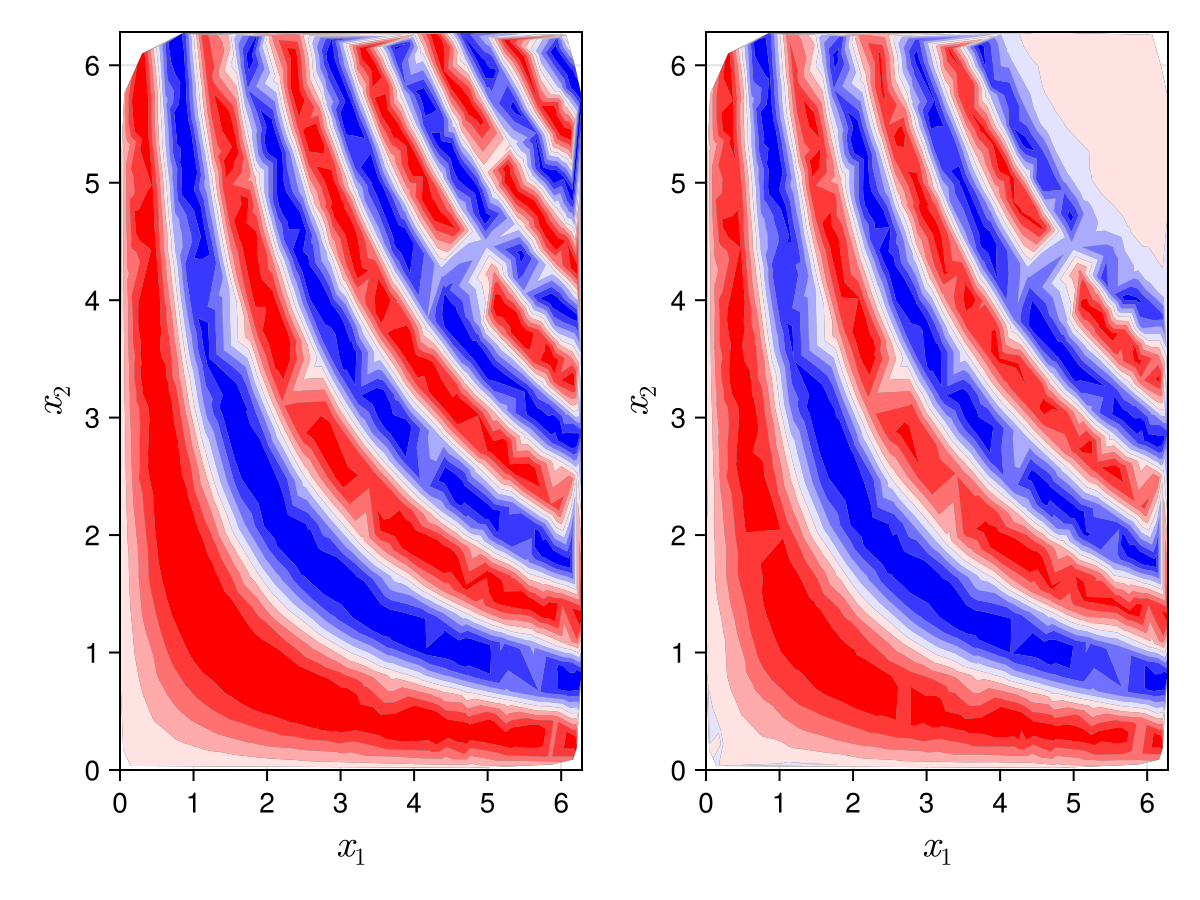

CairoMakie.Screen{IMAGE}


In [16]:
# predict using Neural Network
y_NN,_=model(x_samples,neural_network.u, layer_states) #note that model expects the input as a row vector

fig = Figure(backgroundcolor=:transparent)
ax1 = CairoMakie.Axis(fig[1, 1], xlabel = L"x_1", ylabel = L"x_2",limits=(0,2π,0,2π),xlabelsize = 20,ylabelsize = 20,backgroundcolor=:transparent)
ax2 = CairoMakie.Axis(fig[1, 2], xlabel = L"x_1", ylabel = L"x_2",limits=(0,2π,0,2π),xlabelsize = 20,ylabelsize = 20,backgroundcolor=:transparent)
tricontourf!(ax1,x_samples[1,:],x_samples[2,:],y_samples[:],colormap=:bwr)
tricontourf!(ax2,x_samples[1,:],x_samples[2,:],y_NN[:],colormap=:bwr)
save("../figures/06p04TrainingMultivariateNeuralNetworks02.png",fig)
display(fig)

The left figure is the data and the right figure is the Neural Network prediction.  As we can clearly see, we now have a much better prediction than using 

$f_{model}(x_1,x_2)=a_0+a_1 x_1+a_2 x_2+a_3x_1x_2+a_4 x_1^2+a_5 x_2^2$

Plot loss value vs iteration

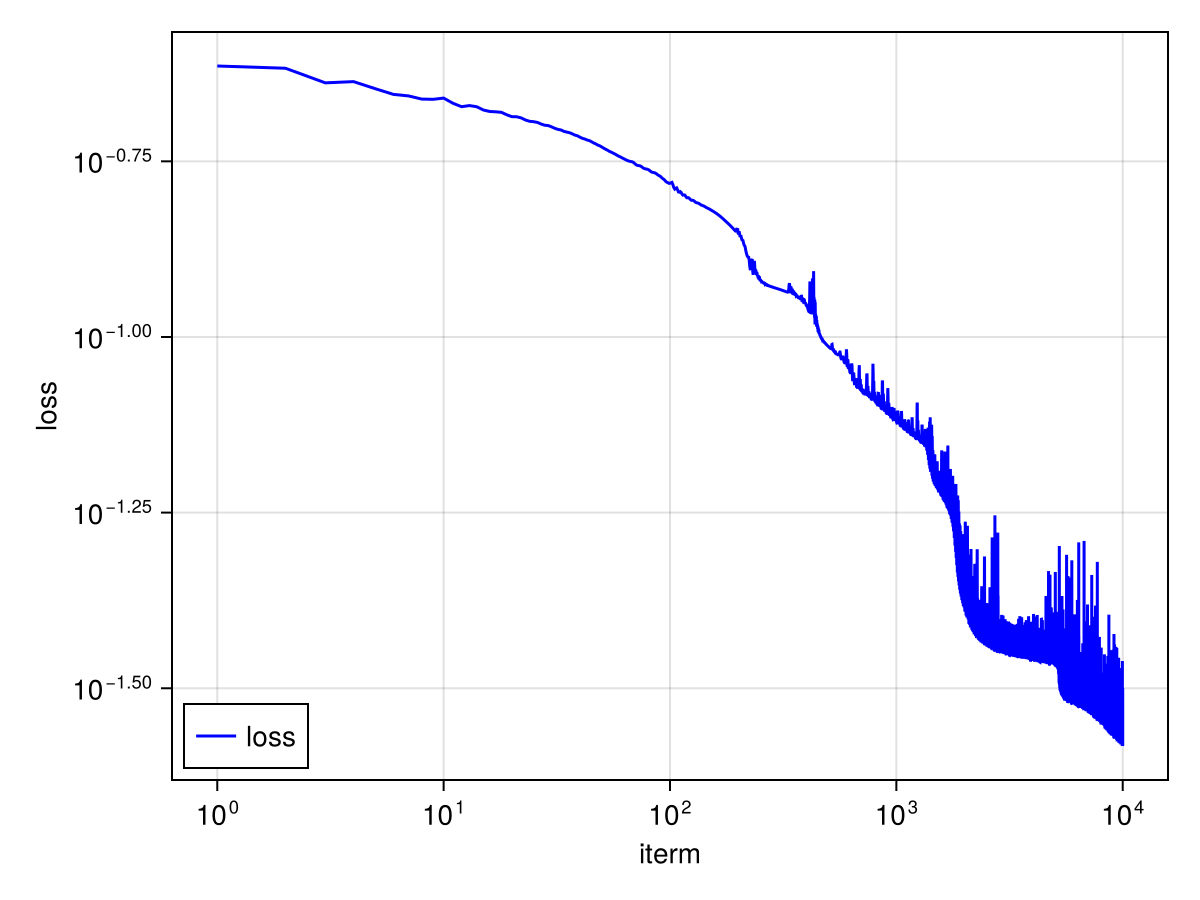

In [17]:
fig = Figure()
ax = CairoMakie.Axis(fig[1, 1], xlabel = "iterm", ylabel = "loss",yscale=log10,xscale=log10)
lines!(ax,loss_history;color=:blue,label="loss")

axislegend(ax,  position = :lb,orientation = :vertical)
fig

This is now better than the results you could obtain in Notebook 3.6

---

Many scientists/engineers would like to be able to do  is to train a neural network on a particular dataset/parameter space and use it to predict at different parameters space.  It would be great if we can make good predictions beyond the parameters the training data.  However, this is often not the case.  Neural Network usually do not do well if asked to predict for inputs that they have not seen.   Let's have a look at the example below.   

![Alt text for screen readers](../figures/06p04TrainingMultivariateNeuralNetworks03.png)

You have a (blue) mass being pulled by a force $r(t)=2e^{-t^2}$.  The location of the mass, $x(t)$ is governed by the equation

$$
\frac{d^2x}{dt^2}+4x=2e^{-t^2}
$$

The physics is such that the velocity at at time $t=1$, $dx/dt(t=1)=0$, i.e. the force somehow stops the mass at time $t=1. 

You have been given 2 sets of measurements, $x(t)$ for $t\in [0,1]$ corresponding to the the initial value of

 * $x(t=0)=0$ and 
 * $x(t=0)=1$

Let's now read and train from one data set and see if we can predict the data from the other data set. 

In [18]:
using CSV
using DataFrames


df = CSV.read("Data07.csv", DataFrame)


Row,xzero,tdata,xdata
,Float64,Float64,Float64
1,0.0,0.0,5.25802e-14
2,0.0,0.02,0.0267462
3,0.0,0.04,0.0542493
4,0.0,0.06,0.0824643
5,0.0,0.08,0.111344
6,0.0,0.1,0.140841
7,0.0,0.12,0.170905
8,0.0,0.14,0.201484
9,0.0,0.16,0.232525


In [19]:
tdata=df[:, :tdata]
xdata=df[:, :xdata]
xzero=df[:, :xzero]

51-element Vector{Float64}:
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 ⋮
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0

This data set has inputs `xzero` and `tdata`.  The output is `xdata`. Let's train a Neural Network to model this dataset 

In order to use the Neural Network, we need to format the data so that the input data looks like

$
t_{input}=\begin{bmatrix}
0&0&0&...& 0 \\
t_1 & t_2 & t_3&  ...& t_{N}
\end{bmatrix}
$

The zeros on the top row corresponds to the value of $x$ at time equals to zero, i.e. $x(t=0)$. The output data should look like

$
\begin{bmatrix}
x_1 & x_2 & x_3&  ...& x_{N}
\end{bmatrix}
$

┌ Warning: Mixed-Precision `matmul_cpu_fallback!` detected and Octavian.jl cannot be used for this set of inputs (C [Matrix{Float64}]: A [Matrix{Float32}] x B [Matrix{Float64}]). Falling back to generic implementation. This may be slow.
└ @ LuxLib.Impl /Users/asho/.julia/packages/LuxLib/zPBrt/src/impl/matmul.jl:194


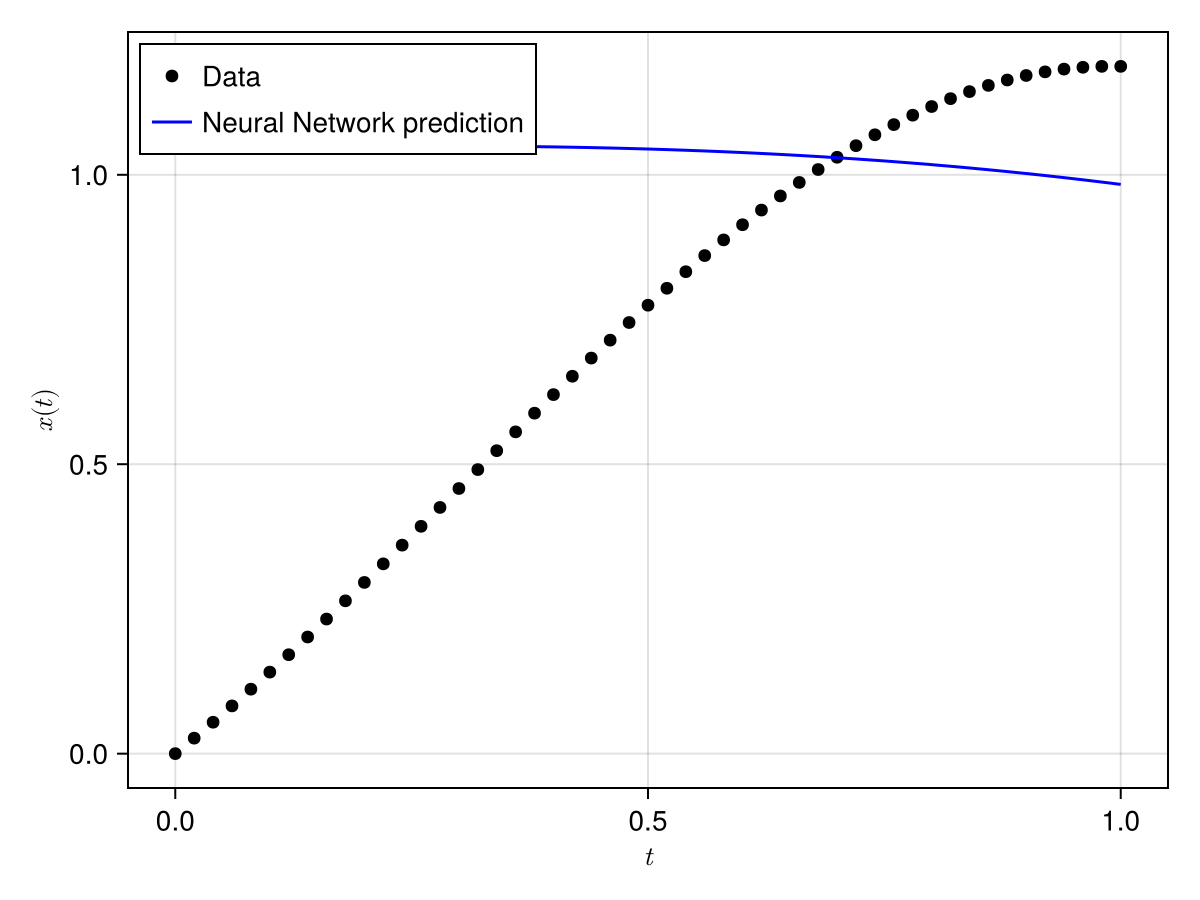

In [20]:
t_input=[xzero';tdata']
model = Chain(
    Dense(2 => 5),
    Dense(5 => 5,tanh),
    Dense(5 => 1)
)
parameters, layer_states = Lux.setup(rng, model)
x_prediction, _= model(t_input,parameters, layer_states)

fig = Figure()
ax = CairoMakie.Axis(fig[1, 1], xlabel = L"t", ylabel = L"x(t)")
scatter!(ax,tdata,xdata;color=:black,label="Data")
lines!(ax,tdata,x_prediction[:];color=:blue,label="Neural Network prediction")
axislegend(position=:lt)
fig

The prediction is not good because we have not trained the Neural Network yet.

Set up the `loss_fn` function

In [21]:
function loss_fn(p, ls)
    x_prediction, new_ls= model(t_input, p, ls)
    loss = 0.5 * mean((x_prediction .- xdata').^2)
    return loss
end

loss_fn (generic function with 1 method)

Let's train the Neural Network on this data set

In [22]:
callback = function (p, l)
    if length(loss_history) % 100 == 0
        println("Iteration: $(p.iter), Loss: $l")
    end
    push!(loss_history, l)
    return false
end

adtype = Optimization.AutoZygote()
optf = Optimization.OptimizationFunction(loss_fn, adtype)
optprob = Optimization.OptimizationProblem(optf, ComponentArray(parameters),layer_states)

# Initialize a vector to store loss values
loss_history = Float64[]
neural_network = Optimization.solve(optprob, OptimizationOptimisers.Adam(0.01); callback, maxiters = 5000)


Iteration: 1, Loss: 0.13270670283732464
Iteration: 101, Loss: 0.0002195829965957153
Iteration: 201, Loss: 6.205694867705257e-5
Iteration: 301, Loss: 4.3463065855056435e-5
Iteration: 401, Loss: 3.0346280496018397e-5
Iteration: 501, Loss: 2.2325660776957894e-5
Iteration: 601, Loss: 1.7846180687330385e-5
Iteration: 701, Loss: 1.5381611022002838e-5
Iteration: 801, Loss: 1.3838949408021406e-5
Iteration: 901, Loss: 1.2610759059903855e-5
Iteration: 1001, Loss: 1.1441376908075665e-5
Iteration: 1101, Loss: 1.0260401099770373e-5
Iteration: 1201, Loss: 9.068262731192654e-6
Iteration: 1301, Loss: 7.881061916809846e-6
Iteration: 1401, Loss: 6.715669723757958e-6
Iteration: 1501, Loss: 5.593153193130644e-6
Iteration: 1601, Loss: 4.5430333027151875e-6
Iteration: 1701, Loss: 3.6014737398164448e-6
Iteration: 1801, Loss: 2.8030053691595755e-6
Iteration: 1901, Loss: 2.16948875063218e-6
Iteration: 2001, Loss: 1.701610533872104e-6
Iteration: 2101, Loss: 1.3783798501738651e-6
Iteration: 2201, Loss: 1.1652225

retcode: Default
u: ComponentVector{Float32}(layer_1 = (weight = Float32[0.9935731 1.0949479; 0.19197696 -0.5294291; … ; 0.20209746 0.7938749; -0.90211725 -0.15952706], bias = Float32[-0.76486814, -0.2778445, -0.4903074, 0.7549496, 0.5107975]), layer_2 = (weight = Float32[-0.55811447 -0.92532825 … -0.66088283 -0.30874166; -2.091233 0.28885508 … -0.35569742 1.1352026; … ; 0.93508 0.83279735 … -0.6388073 0.10907046; -0.9134304 0.2309189 … -1.1135938 0.06625707], bias = Float32[0.46370885, -0.08690347, 0.43033978, 0.28756475, 0.36273134]), layer_3 = (weight = Float32[0.5617595 -0.2708582 … 0.51953876 -0.77428937], bias = Float32[0.30278867]))

In [23]:
x_prediction, new_ls= model(t_input,neural_network.u, layer_states)

([0.0013653268807202533 0.02732418552602813 … 1.188407751229773 1.1902568820454948], (layer_1 = NamedTuple(), layer_2 = NamedTuple(), layer_3 = NamedTuple()))

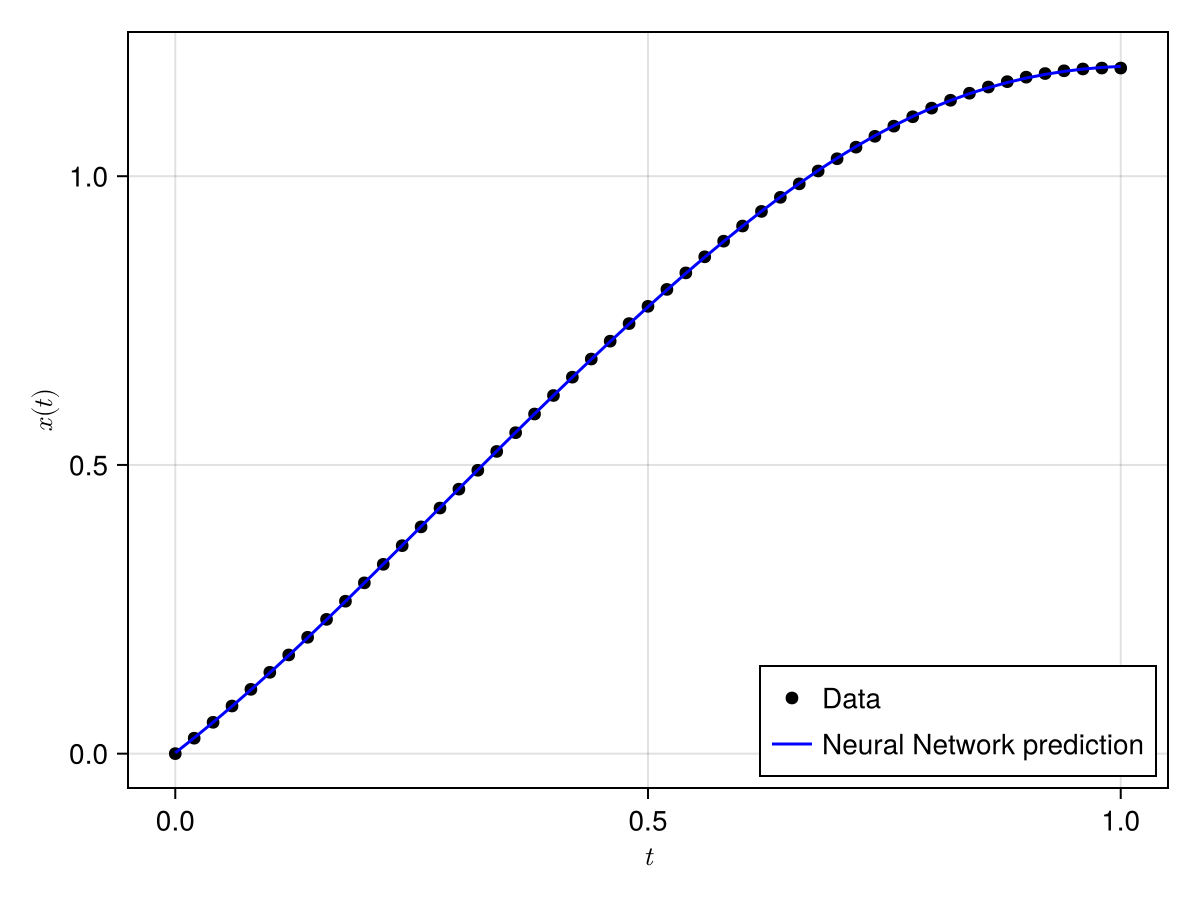

In [24]:
fig = Figure()
ax = CairoMakie.Axis(fig[1, 1], xlabel = L"t", ylabel = L"x(t)")
scatter!(ax,tdata,xdata;color=:black,label="Data")
lines!(ax,tdata,x_prediction[:];color=:blue,label="Neural Network prediction")
axislegend(ax,  position = :rb,orientation = :vertical)
fig

We have managed to fit the data pretty well!

---

Now let's read another data set. This data set is taken from the same physical system as the previous model.  But only the value of xzero has changed.  Let's read "Data08.csv" and inspect its contents

In [25]:
using CSV
using DataFrames


df = CSV.read("Data08.csv", DataFrame)

Row,xzero,tdata,xdata
,Float64,Float64,Float64
1,1.0,0.0,1.0
2,1.0,0.02,0.933765
3,1.0,0.04,0.866836
4,1.0,0.06,0.799318
5,1.0,0.08,0.731319
6,1.0,0.1,0.662945
7,1.0,0.12,0.594301
8,1.0,0.14,0.525496
9,1.0,0.16,0.456634


Observe that the value of `xzero` is now 1.  Let's use the same Neural network to make the prediction and compare with the data from `Data08.csv`

In order to use the Neural Network we have just trained, we have to ensure that the input data looks like

$
t_{input}=\begin{bmatrix}
1&1&1&...& 1 \\
t_1 & t_2 & t_3&  ...& t_{N}
\end{bmatrix}
$

The value of $1$ s on the first row is because the value of $x(t=0)=1$. 

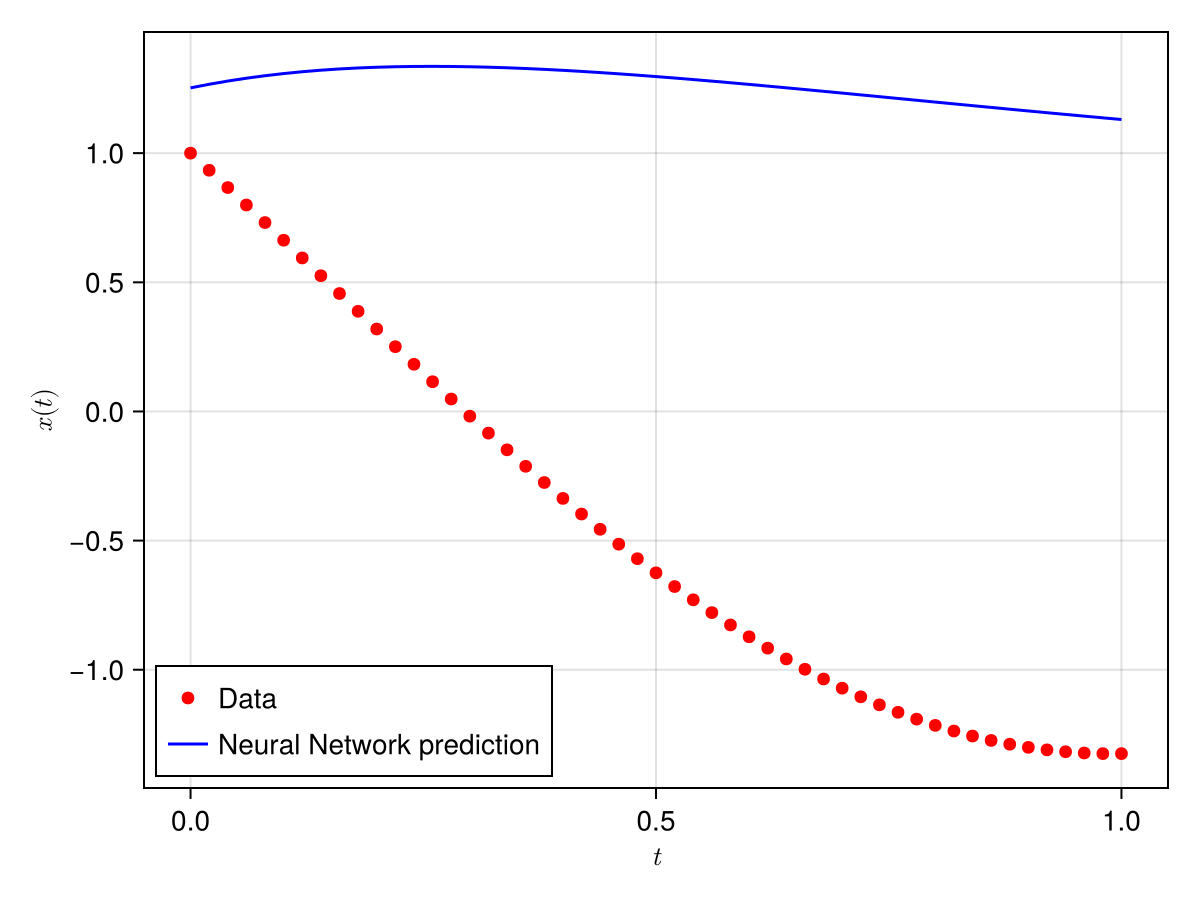

In [26]:
tdata=df[:, :tdata]
xdata=df[:, :xdata]
xzero=df[:, :xzero]
t_input=[xzero';tdata']
x_prediction, new_ls= model(t_input,neural_network.u, layer_states)
fig = Figure()
ax = CairoMakie.Axis(fig[1, 1], xlabel = L"t", ylabel = L"x(t)")
scatter!(ax,tdata,xdata;color=:red,label="Data")
lines!(ax,tdata,x_prediction[:];color=:blue,label="Neural Network prediction")
axislegend(ax,  position = :lb,orientation = :vertical)
fig

As you can see, the Neural Network does not give a good prediction on data that it has not seen before.  We have trained the data when `xzero`  has a value of zero.  However, when we use it to make a prediction for `xzero` equals to 1, it gives terrible predictions. 

---

Now let's train our network on both ($x(0)=0$ and $x(0)=1$) data sets and see if we can predict both data sets. 

In [27]:
using CSV
using DataFrames

df1 = CSV.read("Data07.csv", DataFrame)
tdata1=df1[:, :tdata]
xdata1=df1[:, :xdata]
xzero1=df1[:, :xzero]

df2 = CSV.read("Data08.csv", DataFrame)
tdata2=df2[:, :tdata]
xdata2=df2[:, :xdata]
xzero2=df2[:, :xzero]

51-element Vector{Float64}:
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 ⋮
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0

Let's have a look at the two data sets

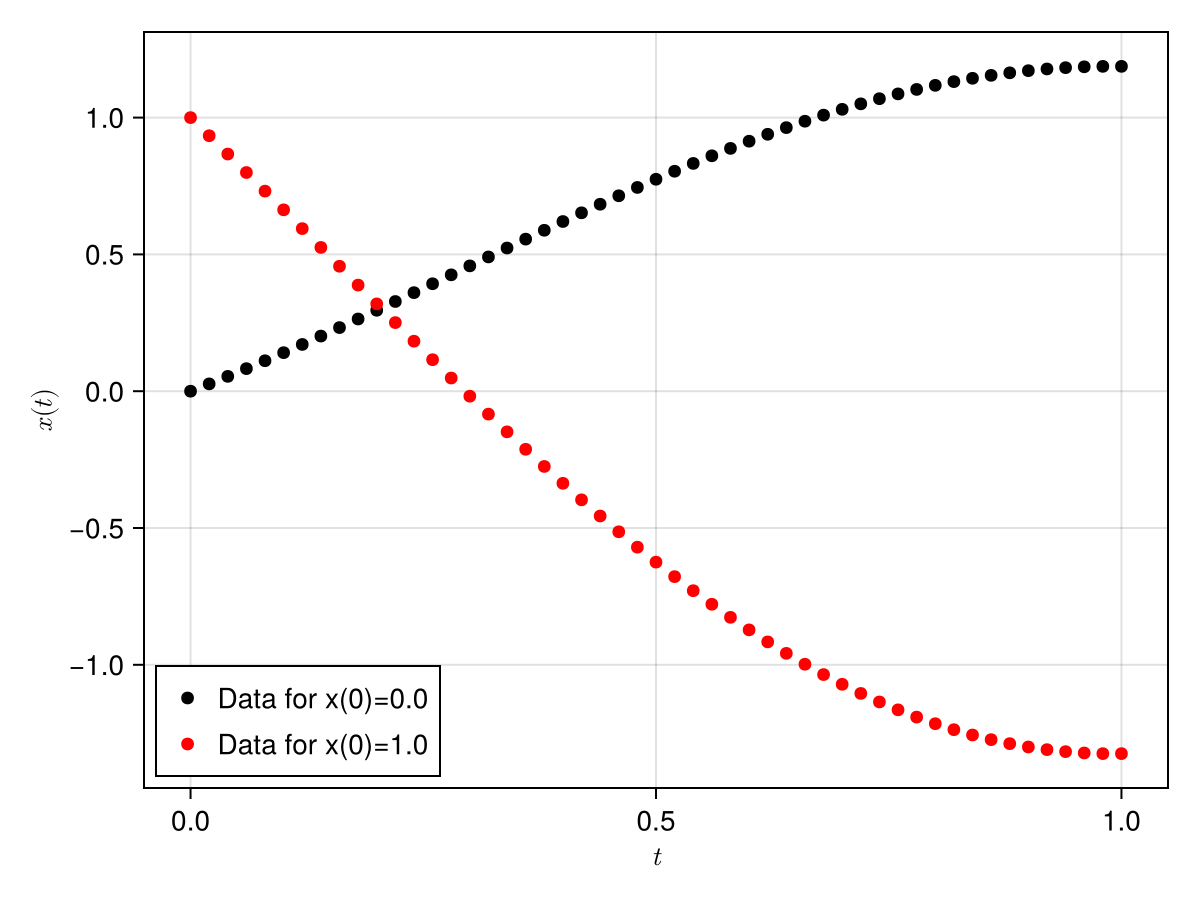

In [28]:
fig = Figure()
ax1 = CairoMakie.Axis(fig[1, 1], xlabel = L"t", ylabel = L"x(t)")
scatter!(ax1,tdata1,xdata1;color=:black,label="Data for x(0)=0.0")
scatter!(ax1,tdata2,xdata2;color=:red,label="Data for x(0)=1.0")
axislegend(ax1,  position = :lb,orientation = :vertical)

fig

Formatting the data for input into the Neural Network model for training.  We need to put in both data from "Data07.csv" and "Data08.csv".  The data has to be formatted as follows

$$
t_{input}=\begin{bmatrix}
0&0&0&...& 0 & 1 & 1 & 1&...&1 \\
t_1&t_2&t_3&...& t_{N} & t_1 & t_2 & t_3&...&t_{N} \\
\end{bmatrix}
$$


The output from the Neural Network would be

\begin{bmatrix}
x_1^{(1)} & x_2^{(1)} & x_3^{(1)}&  ...& x_{N}^{(1)}& x_1^{(2)} & x_2^{(2)} & x_3^{(2)}&  ...& x_{N}^{(2)}
\end{bmatrix}

In [29]:
t_input=vcat(hcat(xzero1', xzero2'),hcat(tdata1', tdata2'))
xdata_combined=hcat(xdata1', xdata2')

1×102 adjoint(::Vector{Float64}) with eltype Float64:
 5.25802e-14  0.0267462  0.0542493  …  -1.32231  -1.32473  -1.32473

In [30]:
model = Chain(
    Dense(2 => 5),
    Dense(5 => 5,tanh),
    Dense(5 => 1)
)
parameters, layer_states = Lux.setup(rng, model)

((layer_1 = (weight = Float32[1.183061 -0.61299354; -0.96052945 -0.122655705; … ; 0.99058926 0.8809008; 0.55624646 -0.769506], bias = Float32[-0.57387185, -0.07378067, 0.5426665, -0.29281884, -0.38988987]), layer_2 = (weight = Float32[0.04001685 -0.022117373 … -1.0208346 0.62015903; -0.08396796 -0.60337377 … 0.9056151 -0.22010043; … ; 0.9678946 -0.6085206 … -0.65937144 -0.76693267; 0.23540057 1.0146302 … 0.12261096 -1.1047238], bias = Float32[0.43545607, -0.026276587, 0.07243845, 0.4435729, -0.39207837]), layer_3 = (weight = Float32[-0.11401739 0.75649184 … 0.22037202 -0.45605305], bias = Float32[-0.3306664])), (layer_1 = NamedTuple(), layer_2 = NamedTuple(), layer_3 = NamedTuple()))

In [31]:
function loss_fn(p, ls)
    x_prediction, new_ls= model(t_input, p, ls)
    loss = 0.5 * mean((x_prediction .- xdata_combined).^2)
    return loss
end

loss_fn (generic function with 1 method)

In [32]:
x_prediction, new_ls= model(t_input, parameters, layer_states)
x_prediction.- xdata_combined

1×102 Matrix{Float64}:
 -0.253356  -0.239999  -0.227333  …  2.22284  2.25493  2.28457  2.31171

In [33]:
loss_fn(parameters, layer_states)

0.46653756860978174

In [34]:
callback = function (p, l)
    if length(loss_history) % 100 == 0
        println("Iteration: $(p.iter), Loss: $l")
    end
    push!(loss_history, l)
    return false
end

adtype = Optimization.AutoZygote()
optf = Optimization.OptimizationFunction(loss_fn, adtype)
optprob = Optimization.OptimizationProblem(optf, ComponentArray(parameters),layer_states)

# Initialize a vector to store loss values
loss_history = Float64[]
neural_network = Optimization.solve(optprob, OptimizationOptimisers.Adam(0.01); callback, maxiters = 5000)

Iteration: 1, Loss: 0.46653756860978174
Iteration: 101, Loss: 0.00800901522463932
Iteration: 201, Loss: 0.0010672144155270185
Iteration: 301, Loss: 0.00045975393125279333
Iteration: 401, Loss: 0.00020113453387498738
Iteration: 501, Loss: 9.313640792046085e-5
Iteration: 601, Loss: 4.895311166143555e-5
Iteration: 701, Loss: 3.0220711025284967e-5
Iteration: 801, Loss: 2.1199768439976745e-5
Iteration: 901, Loss: 1.6285528565284326e-5
Iteration: 1001, Loss: 1.3532689770141038e-5
Iteration: 1101, Loss: 1.20519323878656e-5
Iteration: 1201, Loss: 1.1295614290370818e-5
Iteration: 1301, Loss: 1.0919359229066925e-5
Iteration: 1401, Loss: 1.0726672765811392e-5
Iteration: 1501, Loss: 1.0616059288834712e-5
Iteration: 1601, Loss: 1.0539385348088972e-5
Iteration: 1701, Loss: 1.0475579944928109e-5
Iteration: 1801, Loss: 1.0416065377740632e-5
Iteration: 1901, Loss: 1.0357590773720311e-5
Iteration: 2001, Loss: 1.029899017944531e-5
Iteration: 2101, Loss: 1.0239813949647852e-5
Iteration: 2201, Loss: 1.0179

retcode: Default
u: ComponentVector{Float32}(layer_1 = (weight = Float32[1.4419895 -0.3073582; -1.2470273 0.043071177; … ; 0.92265314 1.2984103; 0.6813292 -1.2057304], bias = Float32[-0.52163833, -0.45106018, 0.68838406, -0.23965093, -0.29626292]), layer_2 = (weight = Float32[0.8690655 0.17651984 … -1.1078001 1.5456083; -0.13954698 -0.93021685 … 1.6369109 -0.51815945; … ; 0.6159845 -0.66013706 … -0.48256117 -1.2526798; 0.45916107 0.70591027 … 0.77829236 -1.6920831], bias = Float32[-0.34307396, 0.17928475, 0.254903, 0.86675596, -0.5948779]), layer_3 = (weight = Float32[0.7740779 0.97001785 … 0.47774854 -0.76818776], bias = Float32[-0.00067993026]))

Now we predict the $x(0)=0$ data. 

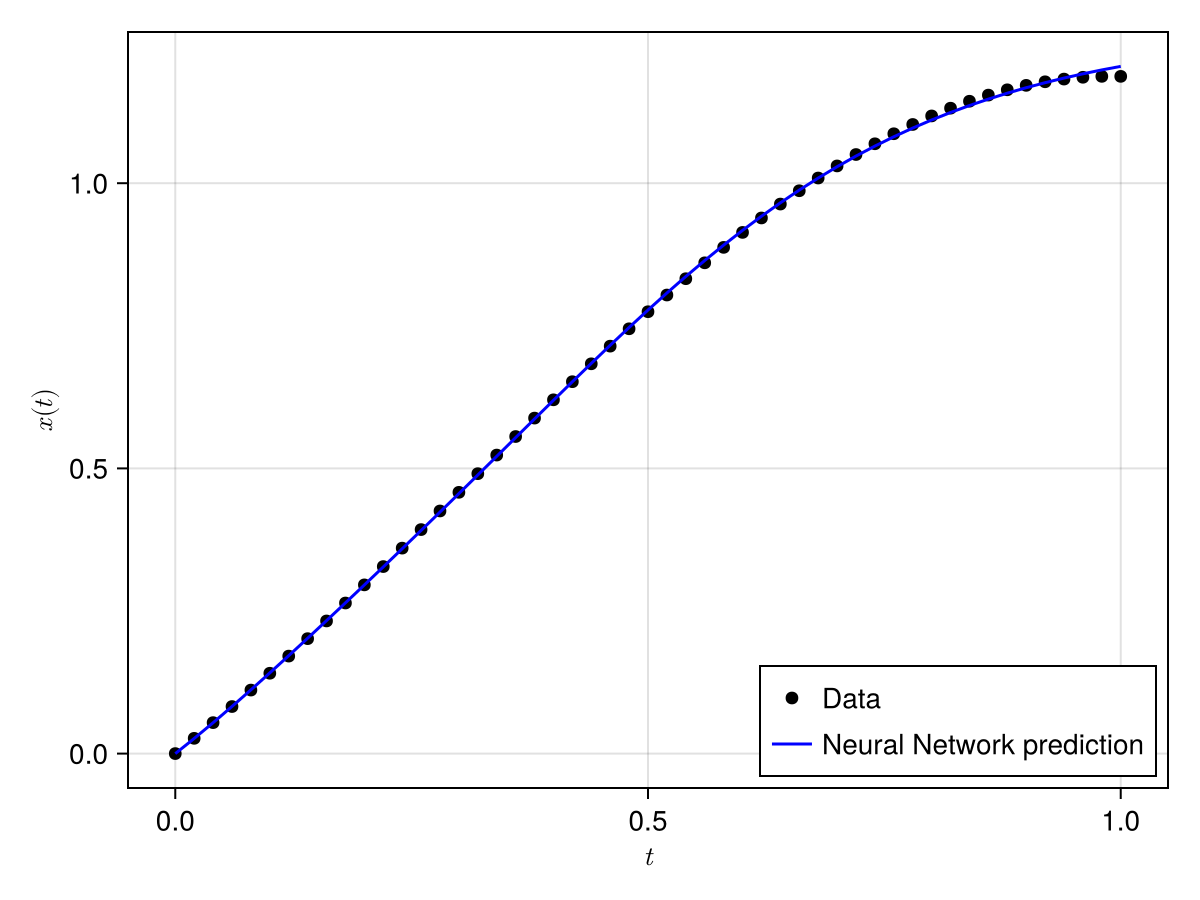

In [35]:
t_input1=[xzero1';tdata1']
x_prediction, new_ls= model(t_input1,neural_network.u, layer_states)
fig = Figure()
ax = CairoMakie.Axis(fig[1, 1], xlabel = L"t", ylabel = L"x(t)")
scatter!(ax,tdata1,xdata1;color=:black,label="Data")
lines!(ax,tdata1,x_prediction[:];color=:blue,label="Neural Network prediction")
axislegend(ax,  position = :rb,orientation = :vertical)
fig

Now we predict the $x(0)=1$ data. 

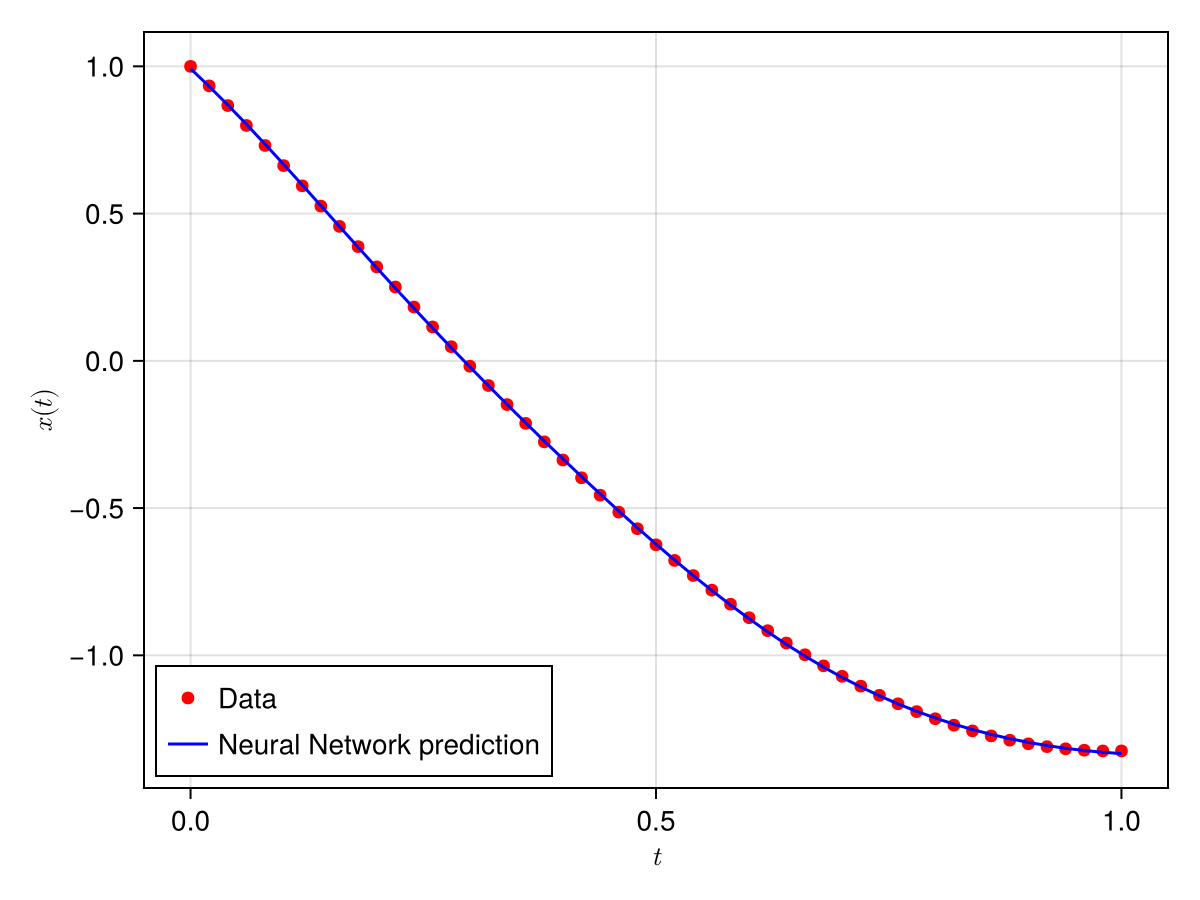

In [36]:
t_input2=[xzero2';tdata2']
x_prediction, new_ls= model(t_input2,neural_network.u, layer_states)
fig = Figure()
ax = CairoMakie.Axis(fig[1, 1], xlabel = L"t", ylabel = L"x(t)")
scatter!(ax,tdata2,xdata2;color=:red,label="Data")
lines!(ax,tdata2,x_prediction[:];color=:blue,label="Neural Network prediction")
axislegend(ax,  position = :lb,orientation = :vertical)
fig